# Factor Allocation Evidence: Diversification Across Return Sources

**Docker image**: `ml4t`

This notebook examines the empirical evidence for factor-based allocation using
a century of data from AQR Capital Management and Kenneth French's Data Library.
The key question for portfolio construction: which factors diversify, which provide
crisis insurance, and what does this mean for allocation decisions?

**Learning Objectives**:
- Assess factor premia reality using 100+ years of pre-discovery data
- Analyze cross-asset evidence from 8 asset classes
- Quantify the value-momentum negative correlation for diversification
- Evaluate trend-following as portfolio insurance during crises
- Understand factor decay (the cautionary tale of the size premium)

**Book Reference**: Chapter 17, §17.4 (Baseline Allocators)

**Prerequisites**: None (uses AQR and Fama-French data, not case study data)

## Data Requirements

### Fama-French Data (automatic)
Data is fetched automatically from Kenneth French's Data Library on first use.

### AQR Data (one-time download required)
AQR factor data must be downloaded once before running this notebook:

```python
from ml4t.data.providers import AQRFactorProvider
AQRFactorProvider.download()  # Downloads ~50MB of Excel files from AQR
```

Both data sources are freely available for academic and research use.

## Setup

In [1]:
"""Factor Allocation Evidence — analyze diversification benefits across return sources using ETF and factor data."""

import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl

# ML4T data providers
from ml4t.data.providers import AQRFactorProvider, FamaFrenchProvider
from plotly.subplots import make_subplots
from scipy import stats

from utils import DATA_DIR

warnings.filterwarnings("ignore")

.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:32: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  self.default_format = "png"
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:33: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  self.default_width = 700
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:34: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  self.default_height = 500
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:35: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be rem

In [2]:
# Production defaults — Papermill overrides for CI testing
# This notebook uses AQR/Fama-French data (no case study data);
# date range is governed by source-provider availability, no parameters needed.

## Initialize Data Providers

The ml4t-data library provides comprehensive access to factor data from both
AQR Capital Management and Kenneth French's Data Library.

In [3]:
# Initialize providers
# Note: First time users should run:
#   AQRFactorProvider.download()  # Downloads ~50MB of Excel files from AQR
# Fama-French data is fetched on demand and cached locally

try:
    aqr = AQRFactorProvider(data_path=DATA_DIR / "factors" / "aqr")
    print(f"AQR Provider: {len(aqr.list_datasets())} datasets available")
    print(f"  Categories: {aqr.list_categories()}")
except FileNotFoundError as err:
    raise RuntimeError(
        "AQR factor data is required for this notebook. Run AQRFactorProvider.download() first."
    ) from err

ff = FamaFrenchProvider(cache_path=DATA_DIR / "factors" / "fama-french")
print(f"\nFama-French Provider: {len(ff.list_datasets())} datasets available")
print(f"  Categories: {ff.list_categories()}")

2026-06-13 00:12:02 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=aqr


2026-06-13 00:12:02 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-13 00:12:02 [info     ] Initialized AQR factor provider data_path=data/factors/aqr name=AQRFactorProvider


AQR Provider: 16 datasets available
  Categories: ['equity_factors', 'portfolios', 'cross_asset', 'long_history', 'optional']
2026-06-13 00:12:02 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=fama_french


2026-06-13 00:12:02 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-13 00:12:02 [info     ] Initialized Fama-French provider cache_path=data/factors/fama-french name=FamaFrenchProvider use_cache=True



Fama-French Provider: 58 datasets available
  Categories: ['factors', 'portfolios', 'industry', 'international', 'breakpoints']


These provider checks look mundane, but they matter because the notebook combines
several sources with different histories and naming conventions. Verifying coverage
up front avoids drawing strong conclusions from mismatched sample periods later on.

## Load Core Factor Data

We'll load the key factor datasets for our analysis:

1. **Fama-French factors**: FF3, FF5, Momentum (1926-present)
2. **AQR factors**: QMJ, BAB, HML Devil (1926-present)
3. **Cross-asset**: VME (1972-present), TSMOM (1985-present)
4. **Long-history**: Century of Factor Premia (1920-present)

In [4]:
# Fama-French core factors
ff3 = ff.fetch("ff3")  # Market, SMB, HML, RF
ff5 = ff.fetch("ff5")  # Adds RMW, CMA
mom = ff.fetch("mom")  # Momentum factor

# Combine into Carhart 4-factor and 6-factor models
ff4 = ff.fetch_combined(["ff3", "mom"])
ff6 = ff.fetch_combined(["ff5", "mom"])

print("Fama-French Data Loaded:")
print(
    f"  FF3: {len(ff3)} months ({ff3['timestamp'].min():%Y-%m} to {ff3['timestamp'].max():%Y-%m})"
)
print(
    f"  FF5: {len(ff5)} months ({ff5['timestamp'].min():%Y-%m} to {ff5['timestamp'].max():%Y-%m})"
)
print(
    f"  MOM: {len(mom)} months ({mom['timestamp'].min():%Y-%m} to {mom['timestamp'].max():%Y-%m})"
)

2026-06-13 00:12:02 [debug    ] Loading from cache             file=data/factors/fama-french/ff3_monthly.parquet name=FamaFrenchProvider


2026-06-13 00:12:02 [info     ] Fetched Fama-French data       columns=5 dataset=ff3 frequency=monthly name=FamaFrenchProvider rows=1196


2026-06-13 00:12:02 [debug    ] Loading from cache             file=data/factors/fama-french/ff5_monthly.parquet name=FamaFrenchProvider


2026-06-13 00:12:02 [info     ] Fetched Fama-French data       columns=7 dataset=ff5 frequency=monthly name=FamaFrenchProvider rows=752


2026-06-13 00:12:02 [debug    ] Loading from cache             file=data/factors/fama-french/mom_monthly.parquet name=FamaFrenchProvider


...

2026-06-13 00:12:02 [debug    ] Loading from cache             file=data/factors/fama-french/ff5_monthly.parquet name=FamaFrenchProvider


2026-06-13 00:12:02 [info     ] Fetched Fama-French data       columns=7 dataset=ff5 frequency=monthly name=FamaFrenchProvider rows=752


2026-06-13 00:12:02 [debug    ] Loading from cache             file=data/factors/fama-french/mom_monthly.parquet name=FamaFrenchProvider


2026-06-13 00:12:02 [info     ] Fetched Fama-French data       columns=2 dataset=mom frequency=monthly name=FamaFrenchProvider rows=1190


Fama-French Data Loaded:
  FF3: 1196 months (1926-07 to 2026-02)
  FF5: 752 months (1963-07 to 2026-02)
  MOM: 1190 months (1927-01 to 2026-02)


In [5]:
# AQR factors (if available)
if aqr:
    # Core equity factors
    qmj = aqr.fetch("qmj_factors")
    bab = aqr.fetch("bab_factors")

    # Cross-asset factors
    vme = aqr.fetch("vme_factors")
    tsmom = aqr.fetch("tsmom")

    # Long-history (century of data!)
    century = aqr.fetch("century_premia")

    print("\nAQR Data Loaded:")
    print(
        f"  QMJ: {len(qmj)} months ({qmj['timestamp'].min():%Y-%m} to {qmj['timestamp'].max():%Y-%m})"
    )
    print(
        f"  BAB: {len(bab)} months ({bab['timestamp'].min():%Y-%m} to {bab['timestamp'].max():%Y-%m})"
    )
    print(
        f"  VME: {len(vme)} months ({vme['timestamp'].min():%Y-%m} to {vme['timestamp'].max():%Y-%m})"
    )
    print(
        f"  TSMOM: {len(tsmom)} months ({tsmom['timestamp'].min():%Y-%m} to {tsmom['timestamp'].max():%Y-%m})"
    )
    print(
        f"  Century: {len(century)} months ({century['timestamp'].min():%Y-%m} to {century['timestamp'].max():%Y-%m})"
    )

2026-06-13 00:12:02 [info     ] Fetched AQR data               columns=29 dataset=qmj_factors name=AQRFactorProvider region=None rows=825


2026-06-13 00:12:02 [info     ] Fetched AQR data               columns=29 dataset=bab_factors name=AQRFactorProvider region=None rows=1144


2026-06-13 00:12:02 [info     ] Fetched AQR data               columns=22 dataset=vme_factors name=AQRFactorProvider region=None rows=650


2026-06-13 00:12:02 [info     ] Fetched AQR data               columns=5 dataset=tsmom name=AQRFactorProvider region=None rows=481


2026-06-13 00:12:02 [info     ] Fetched AQR data               columns=44 dataset=century_premia name=AQRFactorProvider region=None rows=1182



AQR Data Loaded:
  QMJ: 825 months (1957-07 to 2026-03)
  BAB: 1144 months (1930-12 to 2026-03)
  VME: 650 months (1972-01 to 2026-02)
  TSMOM: 481 months (1985-01 to 2025-01)
  Century: 1182 months (1926-07 to 2024-12)


## Return Units and Conventions

The `ml4t.data.providers` library returns all factor data as **monthly decimals**:
- `0.01` = 1% monthly return
- `FamaFrenchProvider`: Divides raw French data (percent) by 100 on fetch
- `AQRFactorProvider`: Returns data as-is (already decimal in source files)

**Terminology**:
- `Mkt-RF`: Market excess return (market return minus risk-free rate)
- `HML`, `SMB`, `MOM`: Long-short factor portfolios (already excess returns)
- Missing values: Excluded from all calculations via `dropna()`

In [6]:
# Convert to pandas for analysis (provider returns Polars)
ff4_pd = ff4.to_pandas().set_index("timestamp")

# Sanity check: verify decimal units (fail if provider has a bug)
for col in ["Mkt-RF", "HML", "SMB", "MOM"]:
    if col in ff4_pd.columns:
        median_abs = ff4_pd[col].dropna().abs().median()
        assert median_abs < 0.20, (
            f"{col}: median |r| = {median_abs:.2f} suggests percent units (provider bug)"
        )

print(
    f"Loaded {len(ff4_pd)} months of Fama-French data, {ff4_pd.index.min():%Y-%m} to {ff4_pd.index.max():%Y-%m}"
)

Loaded 1196 months of Fama-French data, 1926-07 to 2026-02


The unit sanity check is worth keeping in a teaching notebook because factor datasets
are notorious for mixing percent and decimal conventions. A silent unit error would
completely distort every Sharpe ratio and t-statistic that follows.

## Reference Data: NBER Recessions

Source: NBER Business Cycle Dating Committee (https://www.nber.org/research/data/us-business-cycle-expansions-and-contractions).
These are static dates current as of 2023; future recessions will need manual addition.

In [7]:
# NBER recession dates (peak to trough)
RECESSIONS = [
    ("1929-08-01", "1933-03-01"),  # Great Depression
    ("1937-05-01", "1938-06-01"),  # 1937 Recession
    ("1945-02-01", "1945-10-01"),  # Post-WWII
    ("1948-11-01", "1949-10-01"),  # 1948 Recession
    ("1953-07-01", "1954-05-01"),  # 1953 Recession
    ("1957-08-01", "1958-04-01"),  # 1957 Recession
    ("1960-04-01", "1961-02-01"),  # 1960 Recession
    ("1969-12-01", "1970-11-01"),  # 1969 Recession
    ("1973-11-01", "1975-03-01"),  # Oil Crisis
    ("1980-01-01", "1980-07-01"),  # 1980 Recession
    ("1981-07-01", "1982-11-01"),  # Early 80s Recession
    ("1990-07-01", "1991-03-01"),  # 1990 Recession
    ("2001-03-01", "2001-11-01"),  # Dot-com Bust
    ("2007-12-01", "2009-06-01"),  # Global Financial Crisis
    ("2020-02-01", "2020-04-01"),  # COVID-19
]

# Major crisis periods for detailed analysis
CRISES = {
    "1987 Black Monday": ("1987-10-01", "1987-10-31"),
    "1998 LTCM": ("1998-08-01", "1998-10-31"),
    "2000-02 Dot-com": ("2000-03-01", "2002-10-31"),
    "2008-09 GFC": ("2007-10-01", "2009-03-31"),
    "2020 COVID": ("2020-02-01", "2020-03-31"),
    "2022 Inflation": ("2022-01-01", "2022-10-31"),
}

---

# Part 1: A Century of Factor Performance

## Are Factor Premia Real?

One of the strongest criticisms of factor investing is that factor premia were discovered
through data mining on the 1963-1990 period. The **Century of Factor Premia** dataset
from AQR addresses this: 100+ years of data starting in 1920, much of which predates
the academic publication of these factors.

> "The fact that value and momentum premia exist in data that predates their discovery
> provides compelling pre-publication evidence." — Ilmanen et al. (2021)

**Important distinction**: This is "pre-discovery" or "pre-publication" evidence, not
strictly "out-of-sample" in the workflow sense (which would require pre-registration
before seeing any data). The evidence is strong because it's less susceptible to
post hoc window selection.

In [8]:
# Visualization setup
colors = {
    "Mkt-RF": "#1f77b4",  # Blue - Market
    "HML": "#2ca02c",  # Green - Value
    "SMB": "#9467bd",  # Purple - Size
    "MOM": "#d62728",  # Red - Momentum
    "RMW": "#8c564b",  # Brown - Profitability
    "CMA": "#e377c2",  # Pink - Investment
    "QMJ": "#ff7f0e",  # Orange - Quality
    "BAB": "#17becf",  # Cyan - Low-Vol
    "TSMOM": "#bcbd22",  # Olive - Trend
    "Value": "#2ca02c",  # Green
    "Momentum": "#d62728",  # Red
    "Carry": "#ff7f0e",  # Orange
    "Defensive": "#17becf",  # Cyan
}

labels = {
    "Mkt-RF": "Market (Mkt-RF)",
    "HML": "Value (HML)",
    "SMB": "Size (SMB)",
    "MOM": "Momentum (MOM)",
    "RMW": "Profitability (RMW)",
    "CMA": "Investment (CMA)",
    "QMJ": "Quality (QMJ)",
    "BAB": "Low-Vol (BAB)",
    "TSMOM": "Trend (TSMOM)",
}

In [9]:
# Figure 1: Fama-French Factors - A Century of Performance
# NOTE: These are long-short factor portfolios, not implementable strategies.
# Actual implementation involves financing costs, leverage constraints, and capacity limits.

# Calculate cumulative returns (ff4_pd already converted above)
cum_returns = (1 + ff4_pd[["Mkt-RF", "HML", "SMB", "MOM"]]).cumprod()

fig = go.Figure()

for col in ["Mkt-RF", "MOM", "HML", "SMB"]:
    fig.add_trace(
        go.Scatter(
            x=cum_returns.index,
            y=cum_returns[col],
            name=labels.get(col, col),
            line=dict(color=colors.get(col, "#333"), width=2),
            hovertemplate="%{x|%Y-%m}<br>%{y:.2f}x<extra></extra>",
        )
    )

### Add Regime Context to Figure 1

Recession shading separates secular compounding from crisis behavior.

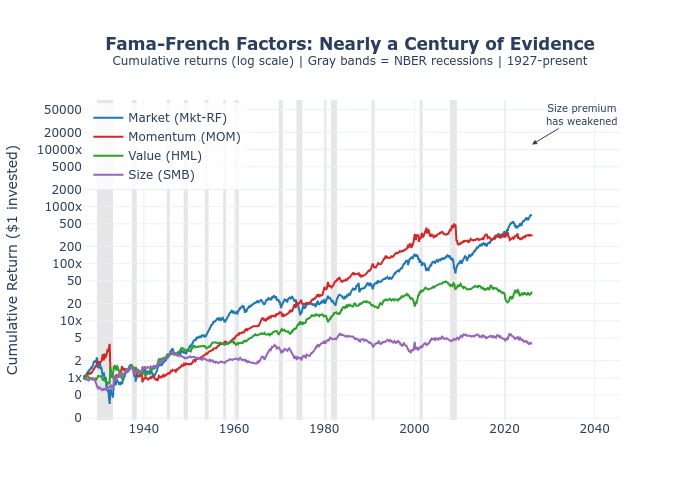

In [10]:
# Add recession bands
for start, end in RECESSIONS:
    start_dt = datetime.strptime(start, "%Y-%m-%d")
    end_dt = datetime.strptime(end, "%Y-%m-%d")
    if start_dt >= cum_returns.index.min():
        fig.add_vrect(
            x0=start_dt, x1=end_dt, fillcolor="gray", opacity=0.2, layer="below", line_width=0
        )

fig.update_layout(
    title=dict(
        text="<b>Fama-French Factors: Nearly a Century of Evidence</b><br>"
        "<sup>Cumulative returns (log scale) | Gray bands = NBER recessions | 1927-present</sup>",
        x=0.5,
    ),
    xaxis_title="",
    yaxis_title="Cumulative Return ($1 invested)",
    yaxis_type="log",
    yaxis=dict(tickformat=".0f", ticksuffix="x"),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor="rgba(255,255,255,0.8)"),
    hovermode="x unified",
    template="plotly_white",
    height=500,
)

# Annotation for size premium weakness
fig.add_annotation(
    x=cum_returns.index[-1],
    y=cum_returns["SMB"].iloc[-1],
    text="Size premium<br>has weakened",
    showarrow=True,
    arrowhead=2,
    ax=50,
    ay=-30,
    font=dict(size=10),
)

fig.show()

### Key Observations

1. **Market (Mkt-RF)**: The equity risk premium has compounded to ~700x over nearly
   a century — the foundation of long-term wealth creation.

2. **Value (HML)**: The value premium is positive over the full Fama-French sample
   used here, with an extended drawdown over 2017-2020 (the "value drawdown").

3. **Momentum (MOM)**: Strong long-term performance but with occasional severe crashes
   (1932, 2009). The 2009 "momentum crash" wiped out years of gains in months.

4. **Size (SMB)**: The size premium has largely disappeared since its discovery in 1981.
   This is a **cautionary tale** about factor decay after publication.

> **Important**: These are **long-short factor portfolio returns**, not tradable
> strategies. The cumulative return charts above represent theoretical wealth paths
> assuming: (1) perfect rebalancing, (2) zero transaction costs, (3) unlimited
> leverage capacity, and (4) no financing costs for short positions. Actual
> implementation of factor strategies involves significant slippage, financing
> costs, and capacity constraints. Use this data as evidence of factor premia
> existence, not as a literal wealth trajectory.

## Figure 2: Century of Factor Premia — Pre-Discovery Evidence

The AQR "Century of Factor Premia" dataset provides pre-discovery evidence for
factor premia. Much of this data (1920-1963) predates the academic publication
of factors, making it less susceptible to post hoc window selection.

Note: "Pre-discovery" is more accurate than "out-of-sample" here. True out-of-sample
would require pre-registration of the strategy before seeing any data.

In [11]:
if century is not None:
    # Get the main factor columns (Stock Selection factors)
    # Century data has columns like: Value Stock Selection, Momentum Stock Selection, etc.
    century_pd = century.to_pandas().set_index("timestamp")
    print(f"Century of Factor Premia: {len(century_pd.columns)} columns, {len(century_pd)} months")
else:
    print("Century data not available - run AQRFactorProvider.download()")

Century of Factor Premia: 44 columns, 1182 months


The century dataset is most persuasive when it covers the pre-publication window.
If it is unavailable, the notebook still runs, but the strongest argument against
post hoc story-telling becomes weaker.

In [12]:
if century is not None:
    # Select key factor series - looking for Stock Selection factors
    factor_cols = []
    for col in century_pd.columns:
        if "Stock Selection" in col or col in ["Value", "Momentum", "Carry", "Defensive"]:
            factor_cols.append(col)

    if not factor_cols:
        # Try alternative column naming
        factor_cols = [
            c
            for c in century_pd.columns
            if any(f in c.lower() for f in ["value", "momentum", "carry", "defensive"])
        ][:4]

    if factor_cols:
        century_factors = century_pd[factor_cols].dropna()
        cum_century = (1 + century_factors).cumprod()
    else:
        print("Could not identify factor columns in Century data")
else:
    print("Skipping century-factor selection - data not available.")

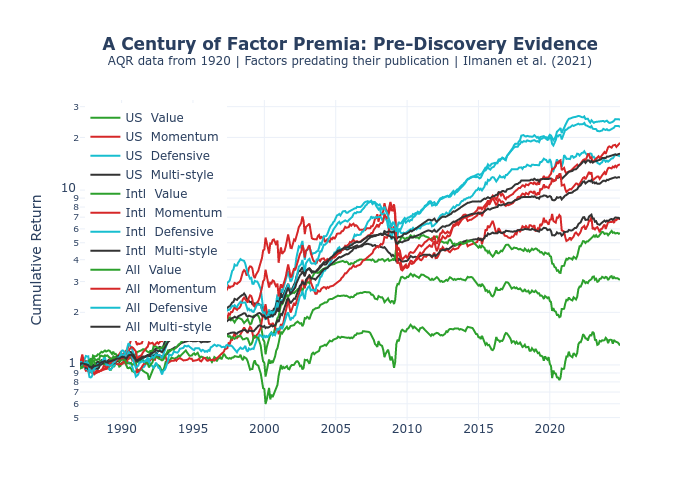

In [13]:
if century is not None and "cum_century" in dir():
    fig = go.Figure()

    for col in cum_century.columns:
        if "value" in col.lower():
            color = colors["Value"]
        elif "momentum" in col.lower():
            color = colors["Momentum"]
        elif "carry" in col.lower():
            color = colors["Carry"]
        elif "defensive" in col.lower():
            color = colors["Defensive"]
        else:
            color = "#333"

        fig.add_trace(
            go.Scatter(
                x=cum_century.index,
                y=cum_century[col],
                name=col.replace("Stock Selection", "").strip(),
                line=dict(color=color, width=2),
                hovertemplate="%{x|%Y-%m}<br>%{y:.2f}x<extra></extra>",
            )
        )

    fig.update_layout(
        title=dict(
            text="<b>A Century of Factor Premia: Pre-Discovery Evidence</b><br>"
            "<sup>AQR data from 1920 | Factors predating their publication | Ilmanen et al. (2021)</sup>",
            x=0.5,
        ),
        xaxis_title="",
        yaxis_title="Cumulative Return",
        yaxis_type="log",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
        template="plotly_white",
        height=500,
    )
    fig.show()

---

## Part 1 Summary: What We've Established (and What We Haven't)

**EXISTENCE EVIDENCE**
- Factor premia exist in long-history data predating their publication
- The data is less susceptible to post hoc window selection
- Multiple factors (value, momentum, carry, defensive) show positive premia

**NOT YET ADDRESSED** (requires separate analysis):
- **Transaction costs**: Turnover, bid-ask spreads, market impact
- **Financing costs**: Short rebates, leverage financing, margin requirements
- **Capacity constraints**: How much capital can these strategies absorb?
- **Implementation drag**: Rebalancing timing, corporate actions, index changes

**The gap between "evidence of premium" and "tradable strategy" is addressed in**:
- Chapter 17: Strategy Simulation (transaction cost modeling)
- Chapter 17: Portfolio Construction (leverage constraints)
- Chapter 19: Transaction Costs (market impact)

---

---

# Part 2: Statistical Rigor — Do Factors Pass Significance Tests?

Harvey, Liu & Zhu (2016) propose a stricter statistical bar for factor discovery:
given hundreds of factors tested in the literature, a **t-stat > 3.0** (not 2.0)
is needed to account for multiple testing.

> "Most claimed research findings in financial economics are likely false."
> — Harvey, Liu & Zhu (2016)

**Important caveats on the t > 3 threshold**:

1. **It applies to mean return t-stats** (HAC-adjusted), not Sharpe ratio significance
2. **It's a proposed bar for cross-sectional factor discovery**, not a universal law
3. **The appropriate threshold depends on context**: pre-registered tests vs. data mining
4. **We apply it here conservatively** to the Newey-West HAC t-stat of mean excess returns

### Mean Return t-statistic (Newey-West HAC)

Harvey et al. (2016) propose t > 3.0 as a stricter bar for factor discovery.
This function computes the Newey-West HAC t-statistic for mean excess returns,
which is what the Harvey threshold applies to.

In [14]:
def calculate_mean_return_tstat(returns, periods_per_year=12):
    """Calculate the Newey-West mean-return t-statistic used in the Harvey test."""
    if hasattr(returns, "values"):
        returns = returns.values
    returns = returns[~np.isnan(returns)]

    n = len(returns)
    if n < 12:
        return {"mean_tstat": np.nan, "mean_return": np.nan, "nw_se_monthly": np.nan}

    mean_ret = np.mean(returns)

    # Newey-West lag selection
    max_lag = int(np.floor(4 * (n / 100) ** (2 / 9)))
    max_lag = max(1, min(max_lag, n // 4))

    # Compute Newey-West HAC variance
    resid = returns - mean_ret
    gamma_0 = np.sum(resid**2) / n

    gamma_sum = 0
    for j in range(1, max_lag + 1):
        weight = 1 - j / (max_lag + 1)  # Bartlett kernel
        gamma_j = np.sum(resid[j:] * resid[:-j]) / n
        gamma_sum += 2 * weight * gamma_j

    nw_var = (gamma_0 + gamma_sum) / n
    nw_se = np.sqrt(max(nw_var, 1e-10))

    mean_tstat = mean_ret / nw_se if nw_se > 0 else 0

    # Annualization: mean_return scales by periods_per_year; nw_se kept monthly.
    # Inference uses mean_tstat (computed on monthly data), not annualized SE.
    return {
        "mean_tstat": mean_tstat,
        "mean_return": mean_ret * periods_per_year,
        "nw_se_monthly": nw_se,
    }

### Sharpe Ratio Statistics (Lo 2002)

The Sharpe ratio t-statistic is **different** from the Harvey threshold.
Lo (2002) derives the asymptotic distribution accounting for serial correlation.

In [15]:
def compute_autocorrelation_adjustment(returns, max_lag: int) -> tuple[list[float], float]:
    autocorrs = []
    for k in range(1, max_lag + 1):
        if len(returns) > k + 1:
            rho_k = np.corrcoef(returns[:-k], returns[k:])[0, 1]
            autocorrs.append(np.clip(rho_k, -0.95, 0.95))
        else:
            autocorrs.append(0.0)

    lr_var_factor = 1.0
    for k, rho_k in enumerate(autocorrs, start=1):
        weight = 1 - k / (max_lag + 1)
        lr_var_factor += 2 * weight * rho_k
    return autocorrs, max(lr_var_factor, 0.1)

Reuse the autocorrelation adjustment inside the Sharpe function so the notebook can
keep the statistical assumptions explicit without burying them in one large cell.

In [16]:
def calculate_sharpe_stats(returns, periods_per_year=12):
    """Calculate annualized Sharpe statistics with Lo-style serial-correlation adjustment."""
    if hasattr(returns, "values"):
        returns = returns.values
    returns = returns[~np.isnan(returns)]

    n = len(returns)
    mean_ret = np.mean(returns) * periods_per_year
    std_ret = np.std(returns, ddof=1) * np.sqrt(periods_per_year)
    sharpe = mean_ret / std_ret if std_ret > 0 else 0

    max_lag = int(np.floor(4 * (n / 100) ** (2 / 9)))
    max_lag = max(1, min(max_lag, n // 4))
    autocorrs, lr_var_factor = compute_autocorrelation_adjustment(returns, max_lag)
    se_iid = np.sqrt((1 + 0.5 * sharpe**2) / n)
    se_sharpe = se_iid * np.sqrt(lr_var_factor)
    sharpe_tstat = sharpe / se_sharpe if se_sharpe > 0 else 0

    ci_lower = sharpe - 1.96 * se_sharpe
    ci_upper = sharpe + 1.96 * se_sharpe
    p_value = 2 * (1 - stats.norm.cdf(abs(sharpe_tstat)))
    mean_stats = calculate_mean_return_tstat(returns, periods_per_year)
    rho1 = autocorrs[0] if autocorrs else 0.0

    return {
        "sharpe": sharpe,
        "sharpe_tstat": sharpe_tstat,
        "t_stat": mean_stats["mean_tstat"],
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ann_return": mean_ret,
        "ann_vol": std_ret,
        "n_months": n,
        "autocorr": rho1,
        "lr_var_factor": lr_var_factor,
    }

### Maximum Drawdown

Simple utility for computing peak-to-trough drawdown.

In [17]:
def calculate_max_drawdown(returns):
    """Calculate maximum drawdown from return series."""
    if hasattr(returns, "values"):
        returns = returns.values
    returns = returns[~np.isnan(returns)]
    cum_returns = np.cumprod(1 + returns)
    rolling_max = np.maximum.accumulate(cum_returns)
    drawdowns = cum_returns / rolling_max - 1
    return np.min(drawdowns)

### Compute Factor Statistics

Apply the statistical functions to all available factors from Fama-French and AQR.

In [18]:
# Calculate statistics for all factors
factor_stats = {}

# Fama-French factors (full history)
for col in ["Mkt-RF", "HML", "SMB", "MOM"]:
    if col in ff4_pd.columns:
        factor_stats[col] = calculate_sharpe_stats(ff4_pd[col].dropna())

# FF5 additional factors (convert once, reuse)
ff5_pd = ff5.to_pandas().set_index("timestamp")
for col in ["RMW", "CMA"]:
    if col in ff5_pd.columns:
        factor_stats[col] = calculate_sharpe_stats(ff5_pd[col].dropna())

# AQR factors
if qmj is not None:
    qmj_pd = qmj.to_pandas().set_index("timestamp")
    if "USA" in qmj_pd.columns:
        factor_stats["QMJ"] = calculate_sharpe_stats(qmj_pd["USA"].dropna())
    elif "Global" in qmj_pd.columns:
        factor_stats["QMJ"] = calculate_sharpe_stats(qmj_pd["Global"].dropna())

if bab is not None:
    bab_pd = bab.to_pandas().set_index("timestamp")
    if "USA" in bab_pd.columns:
        factor_stats["BAB"] = calculate_sharpe_stats(bab_pd["USA"].dropna())
    elif "Global" in bab_pd.columns:
        factor_stats["BAB"] = calculate_sharpe_stats(bab_pd["Global"].dropna())

In [19]:
# Format the factor summary for display.
stats_df = pd.DataFrame(factor_stats).T
stats_df["significant_harvey"] = stats_df["t_stat"] > 3.0  # Mean return t-stat

# Format for display
display_df = stats_df[
    ["ann_return", "ann_vol", "sharpe", "t_stat", "sharpe_tstat", "significant_harvey"]
].copy()
display_df.columns = [
    "Ann. Return",
    "Ann. Vol",
    "Sharpe",
    "Mean t (NW)",
    "Sharpe t",
    "Harvey (t>3)",
]

# Style and display
display_df.style.format(
    {
        "Ann. Return": "{:.1%}",
        "Ann. Vol": "{:.1%}",
        "Sharpe": "{:.2f}",
        "Mean t (NW)": "{:.1f}",
        "Sharpe t": "{:.1f}",
    }
)

,Ann. Return,Ann. Vol,Sharpe,Mean t (NW),Sharpe t,Harvey (t>3)
Mkt-RF,8.3%,18.4%,0.45,4.4,14.4,True
HML,4.2%,12.3%,0.34,3.1,10.4,True
SMB,2.0%,10.9%,0.18,1.8,6.0,False
MOM,7.3%,16.2%,0.45,4.6,15.3,True
RMW,3.2%,7.7%,0.42,3.0,9.9,False
CMA,3.0%,7.2%,0.42,2.9,9.6,False
QMJ,4.0%,7.8%,0.50,3.7,12.0,True
BAB,7.9%,11.1%,0.71,5.7,17.6,True


**Column definitions:**
- *Mean t (NW)*: Newey-West HAC t-statistic for mean excess returns (Harvey threshold applies here)
- *Sharpe t*: t-stat for Sharpe ratio significance (Lo 2002 methodology)
- *Harvey (t>3)*: Whether mean return t-stat exceeds Harvey et al. (2016) threshold

In [20]:
display_df

,Ann. Return,Ann. Vol,Sharpe,Mean t (NW),Sharpe t,Harvey (t>3)
Mkt-RF,0.082832,0.183713,0.450878,4.353369,14.361874,True
HML,0.042250,0.123112,0.343182,3.103763,10.444396,True
SMB,0.019904,0.109122,0.182405,1.751176,6.013875,False
MOM,0.073425,0.162114,0.452922,4.631735,15.274651,True
RMW,0.031963,0.076903,0.415625,2.982406,9.904947,False
CMA,0.029925,0.071665,0.417567,2.894978,9.607058,False
QMJ,0.039582,0.078390,0.504939,3.683147,12.008200,True
BAB,0.078711,0.111298,0.707209,5.679956,17.584514,True


**Interpretation**: The table separates economic magnitude from statistical strength.
Market and momentum usually clear the stricter Harvey-style bar, while size often
looks weak once serial correlation and multiple-testing concerns are acknowledged.

In [21]:
factor_order = ["Mkt-RF", "MOM", "HML", "RMW", "CMA", "QMJ", "BAB", "SMB"]
factor_order = [f for f in factor_order if f in factor_stats]

In [22]:
# Figure 3: Sharpe Ratios with Confidence Intervals
fig = go.Figure()

for i, factor in enumerate(factor_order):
    s = factor_stats[factor]
    color = colors.get(factor, "#333")

    # Error bar (confidence interval)
    fig.add_trace(
        go.Scatter(
            x=[i, i],
            y=[s["ci_lower"], s["ci_upper"]],
            mode="lines",
            line=dict(color=color, width=4),
            showlegend=False,
            hoverinfo="skip",
        )
    )

    # Point estimate
    fig.add_trace(
        go.Scatter(
            x=[i],
            y=[s["sharpe"]],
            mode="markers",
            marker=dict(color=color, size=15, line=dict(color="white", width=2)),
            name=labels.get(factor, factor),
            hovertemplate=f"<b>{labels.get(factor, factor)}</b><br>"
            f"Sharpe: {s['sharpe']:.2f}<br>"
            f"t-stat: {s['t_stat']:.1f}<br>"
            f"95% CI: [{s['ci_lower']:.2f}, {s['ci_upper']:.2f}]<extra></extra>",
        )
    )

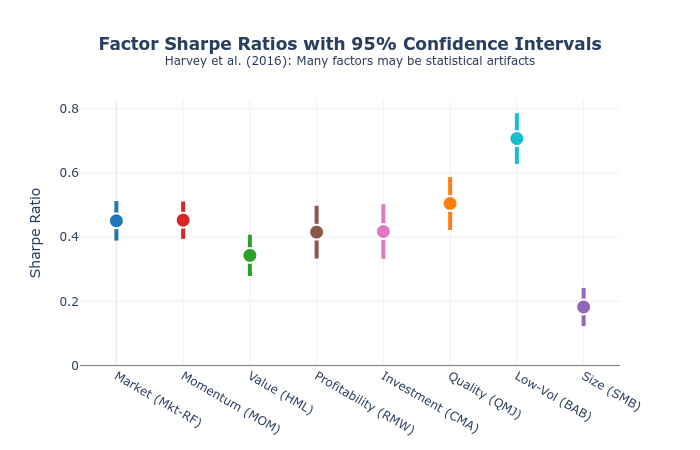

In [23]:
# Reference lines
fig.add_hline(y=0, line_dash="solid", line_color="gray", line_width=1)
# Note: Harvey's t>3 threshold applies to mean return t-stats, not Sharpe ratios.
# The relationship between Sharpe and mean-return t-stat depends on sample size
# and volatility. We show a reference line at SR=0.3 for visual orientation only.

fig.update_layout(
    title=dict(
        text="<b>Factor Sharpe Ratios with 95% Confidence Intervals</b><br>"
        "<sup>Harvey et al. (2016): Many factors may be statistical artifacts</sup>",
        x=0.5,
    ),
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(len(factor_order))),
        ticktext=[labels.get(f, f) for f in factor_order],
    ),
    yaxis_title="Sharpe Ratio",
    showlegend=False,
    template="plotly_white",
    height=450,
)

fig.show()

### Key Observations on Statistical Significance

**Important methodological note**: The t-statistics above are Newey-West HAC
corrected t-stats for mean returns, which is what Harvey et al. (2016) use for
their t > 3 threshold under multiple testing. This is different from the t-stat
of the Sharpe ratio (Lo, 2002), which tests whether SR differs from zero.

1. **Market Risk Premium**: The most statistically significant factor, with mean
   return t-stat typically > 4.0. This is the foundation of equity investing.

2. **Momentum**: Strong statistical significance despite occasional crashes. The
   premium has persisted for nearly a century.

3. **Value (HML)**: Significant but with wider confidence intervals. Recent
   underperformance (2017-2020) has reduced its t-statistic.

4. **Size (SMB)**: The weakest statistical case. The premium has largely disappeared
   since its discovery, raising questions about data mining.

---

# Part 3: Value and Momentum Everywhere

Asness, Moskowitz & Pedersen (2013) document value and momentum premia not just in US
equities, but across **8 different asset classes globally** — a result that mitigates
the single-market data-mining critique applied to factor work on US equities alone.

> "We find consistent value and momentum return premia across eight diverse markets
> and asset classes." — Asness, Moskowitz & Pedersen (2013)

In [24]:
if vme is not None:
    vme_pd = vme.to_pandas().set_index("timestamp")
    print(f"VME data: {len(vme_pd.columns)} columns, {len(vme_pd)} months")
else:
    print("VME data not available - run AQRFactorProvider.download()")

VME data: 22 columns, 650 months


Map AQR VME column suffixes (`VALLS_VME_XX90`, `MOMLS_VME_XX90`) to
display labels. `EQ`, `FX`, `FI`, `COM` cover cross-asset buckets;
`US90`, `UK90`, `ROE90`, `JP90` cover regional equity blocks.

In [25]:
if vme is not None:
    asset_class_map = {
        "US90": "US Equities",
        "UK90": "UK Equities",
        "ROE90": "Europe ex-UK",
        "JP90": "Japan",
        "EQ": "All Equities",
        "FX": "Currencies",
        "FI": "Fixed Income",
        "COM": "Commodities",
    }
    vme_stats = []

Aggregate value/momentum row (the "Everywhere" line) — uses the bundled
`VAL` / `MOM` columns rather than any single asset class.

In [26]:
if vme is not None and "VAL" in vme_pd.columns and "MOM" in vme_pd.columns:
    val_data = vme_pd["VAL"].dropna()
    mom_data = vme_pd["MOM"].dropna()
    if len(val_data) > 12 and len(mom_data) > 12:
        val_stats = calculate_sharpe_stats(val_data)
        mom_stats = calculate_sharpe_stats(mom_data)
        common_idx = val_data.index.intersection(mom_data.index)
        corr = val_data[common_idx].corr(mom_data[common_idx])
        vme_stats.append(
            {
                "Asset Class": "EVERYWHERE",
                "Value SR": val_stats["sharpe"],
                "Value t": val_stats["t_stat"],
                "Momentum SR": mom_stats["sharpe"],
                "Momentum t": mom_stats["t_stat"],
                "Val-Mom Corr": corr,
            }
        )

In [27]:
if vme is not None:
    # Then add by asset class
    for suffix, display_name in asset_class_map.items():
        val_col = f"VALLS_VME_{suffix}"
        mom_col = f"MOMLS_VME_{suffix}"

        if val_col in vme_pd.columns and mom_col in vme_pd.columns:
            val_data = vme_pd[val_col].dropna()
            mom_data = vme_pd[mom_col].dropna()

            if len(val_data) > 12 and len(mom_data) > 12:
                val_stats = calculate_sharpe_stats(val_data)
                mom_stats = calculate_sharpe_stats(mom_data)
                common_idx = val_data.index.intersection(mom_data.index)
                corr = val_data[common_idx].corr(mom_data[common_idx])

                vme_stats.append(
                    {
                        "Asset Class": display_name,
                        "Value SR": val_stats["sharpe"],
                        "Value t": val_stats["t_stat"],
                        "Momentum SR": mom_stats["sharpe"],
                        "Momentum t": mom_stats["t_stat"],
                        "Val-Mom Corr": corr,
                    }
                )

In [28]:
if vme is not None and "vme_stats" in dir():
    if vme_stats:
        vme_df = pd.DataFrame(vme_stats)
        vme_df
    else:
        print("Could not parse VME factor columns - check column naming convention")
else:
    print("Skipping VME analysis - data not available.")

**Interpretation**: The cross-asset table matters more than any single region. If
value and momentum both survive across equities, rates, FX, and commodities, the
case for a shared underlying premium is much stronger than a US-only backtest.

Figure 4 setup — two-panel subplot frame: Sharpe ratios by asset class
on the left, value-momentum correlation on the right.

In [29]:
if vme is not None and "vme_stats" in dir() and vme_stats:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("Sharpe Ratios by Asset Class", "Value-Momentum Correlation"),
    )

Left panel — Sharpe-ratio bars for Value and Momentum side-by-side.

In [30]:
if vme is not None and "vme_stats" in dir() and vme_stats:
    fig.add_trace(
        go.Bar(
            x=vme_df["Asset Class"],
            y=vme_df["Value SR"],
            name="Value",
            marker_color=colors["Value"],
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=vme_df["Asset Class"],
            y=vme_df["Momentum SR"],
            name="Momentum",
            marker_color=colors["Momentum"],
        ),
        row=1,
        col=1,
    )

Right panel — value-momentum correlation, colored green for negative
(diversifying) and red for positive.

In [31]:
if vme is not None and "vme_stats" in dir() and vme_stats:
    fig.add_trace(
        go.Bar(
            x=vme_df["Asset Class"],
            y=vme_df["Val-Mom Corr"],
            name="Correlation",
            marker_color=vme_df["Val-Mom Corr"].apply(lambda x: "#d62728" if x > 0 else "#2ca02c"),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

In [32]:
if vme is not None and "vme_stats" in dir() and vme_stats:
    fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=2)

    fig.update_layout(
        title=dict(
            text="<b>Value and Momentum Everywhere: Cross-Asset Evidence</b><br>"
            "<sup>Negative correlation enables diversification | Asness, Moskowitz & Pedersen (2013)</sup>",
            x=0.5,
        ),
        barmode="group",
        template="plotly_white",
        height=450,
        legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.45),
    )
    fig.update_yaxes(title_text="Sharpe Ratio", row=1, col=1)
    fig.update_yaxes(title_text="Correlation", row=1, col=2)
else:
    print("Skipping VME figure - data not available or no valid asset classes found.")

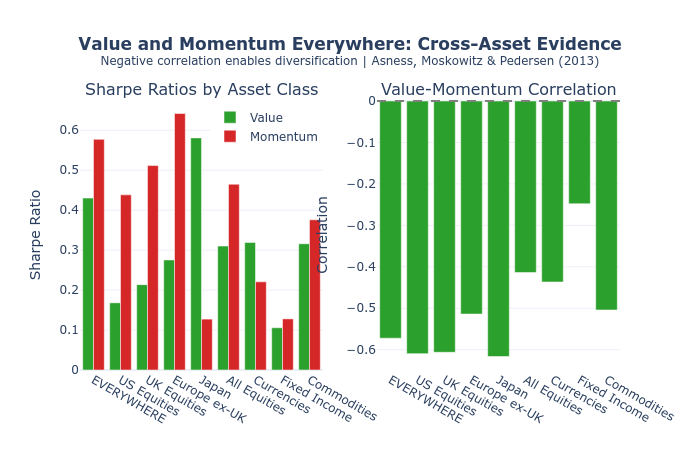

In [33]:
if vme is not None and "vme_stats" in dir() and vme_stats:
    fig.show()

### The Diversification Benefit

A crucial finding is that **value and momentum are negatively correlated** both
within and across asset classes. This natural diversification means combining
value and momentum strategies improves risk-adjusted returns.

The negative correlation arises because:
- Value buys beaten-down assets (past losers that are now cheap)
- Momentum buys recent winners (past winners with positive trend)

These are opposite bets on mean reversion vs. trend continuation.

---

# Part 4: Factor Correlations and Diversification

In [34]:
# Build combined factor dataset for correlation analysis
# Use common period when all factors are available (1972+)

# Start with Fama-French 6 factors
# Cast timestamp to microseconds for consistent join precision
combined_pl = ff6.select(["timestamp", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM"]).with_columns(
    pl.col("timestamp").cast(pl.Datetime("us"))
)

# Add AQR factors if available
if qmj is not None and "USA" in qmj.columns:
    qmj_usa = qmj.select([pl.col("timestamp"), pl.col("USA").alias("QMJ")]).with_columns(
        pl.col("timestamp").cast(pl.Datetime("us"))
    )
    combined_pl = combined_pl.join(qmj_usa, on="timestamp", how="full", coalesce=True)

if bab is not None and "USA" in bab.columns:
    bab_usa = bab.select([pl.col("timestamp"), pl.col("USA").alias("BAB")]).with_columns(
        pl.col("timestamp").cast(pl.Datetime("us"))
    )
    combined_pl = combined_pl.join(bab_usa, on="timestamp", how="full", coalesce=True)

# Filter to common period (1972+) and drop nulls
combined_pl = combined_pl.filter(pl.col("timestamp") >= pl.date(1972, 1, 1)).drop_nulls()

print(
    f"Common period for correlation analysis: {combined_pl['timestamp'].min():%Y-%m} to {combined_pl['timestamp'].max():%Y-%m}"
)
print(f"Factors: {[c for c in combined_pl.columns if c != 'timestamp']}")
print(f"Observations: {len(combined_pl)} months")

# Convert to pandas only for correlation and visualization
combined_data = combined_pl.to_pandas().set_index("timestamp")

Common period for correlation analysis: 1972-01 to 2026-02
Factors: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM', 'QMJ', 'BAB']
Observations: 650 months


In [35]:
# Figure 5: Factor Correlation Matrix
corr_matrix = combined_data.corr()

# Create labels for display
corr_labels = {col: labels.get(col, col) for col in corr_matrix.columns}
corr_display = corr_matrix.copy()
corr_display.index = [corr_labels.get(c, c) for c in corr_display.index]
corr_display.columns = [corr_labels.get(c, c) for c in corr_display.columns]

Draw the heatmap with a diverging red-blue palette centered at zero.

In [36]:
fig = px.imshow(
    corr_display,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="equal",
)

Layout — title, template, dimensions.

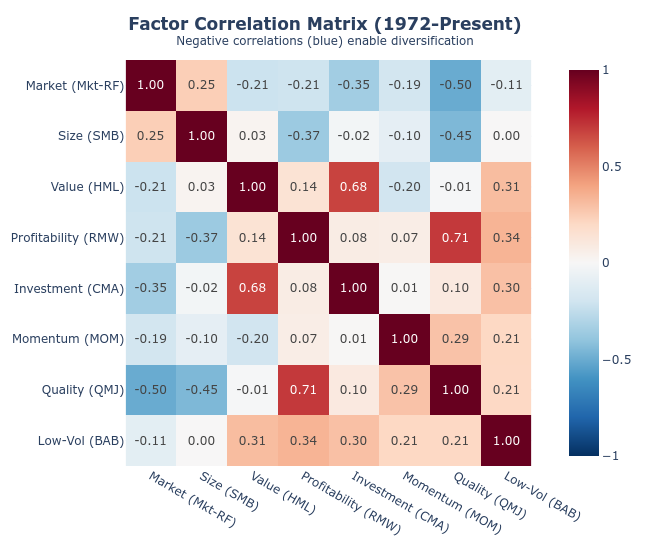

In [37]:
fig.update_layout(
    title=dict(
        text="<b>Factor Correlation Matrix (1972-Present)</b><br>"
        "<sup>Negative correlations (blue) enable diversification</sup>",
        x=0.5,
    ),
    template="plotly_white",
    height=550,
    width=650,
)

Annotation — call out the headline value-momentum negative correlation.

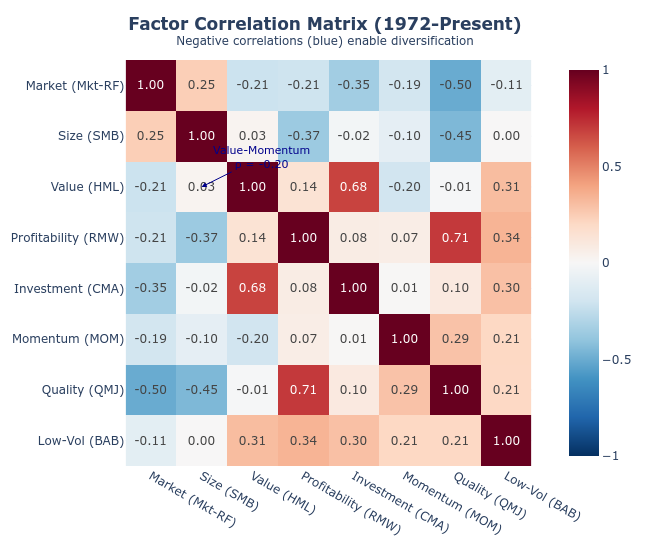

In [38]:
val_mom_corr = (
    corr_matrix.loc["HML", "MOM"]
    if "HML" in corr_matrix.index and "MOM" in corr_matrix.columns
    else None
)
if val_mom_corr is not None:
    fig.add_annotation(
        x=1,
        y=2,
        text=f"Value-Momentum<br>ρ = {val_mom_corr:.2f}",
        showarrow=True,
        arrowhead=2,
        ax=60,
        ay=-30,
        font=dict(size=11, color="darkblue"),
        arrowcolor="darkblue",
    )

fig.show()

### Key Correlation Insights

1. **Value vs. Momentum (ρ ≈ -0.2)**: The famous negative correlation that enables
   diversification. Combining these factors smooths returns.

2. **Quality (QMJ) vs. Market**: QMJ has low market beta, providing defensive
   characteristics during equity downturns.

3. **Low-Vol (BAB) vs. Market**: BAB is designed to be market-neutral but may still
   have residual market exposure during extreme moves.

---

# Part 5: Crisis Performance — Who Provides "Crisis Alpha"?

One of the most important questions for portfolio construction: **Which factors
perform well during market crises?** True "crisis alpha" — positive returns during
equity market drawdowns — is extremely valuable.

Trend-following (time series momentum) has historically provided the best crisis
alpha, essentially acting as portfolio insurance.

In [39]:
# Calculate crisis period returns
crisis_factors = ["Mkt-RF", "HML", "SMB", "MOM"]
if "QMJ" in combined_data.columns:
    crisis_factors.append("QMJ")
if "BAB" in combined_data.columns:
    crisis_factors.append("BAB")

crisis_returns = {}
for crisis_name, (start, end) in CRISES.items():
    start_dt = pd.to_datetime(start)
    end_dt = pd.to_datetime(end)

    mask = (combined_data.index >= start_dt) & (combined_data.index <= end_dt)
    crisis_data = combined_data[mask]

    if len(crisis_data) > 0:
        crisis_returns[crisis_name] = {}
        for col in crisis_factors:
            if col in crisis_data.columns:
                data = crisis_data[col].dropna()
                if len(data) > 0:
                    cum_ret = (1 + data).prod() - 1
                    crisis_returns[crisis_name][col] = cum_ret

crisis_df = pd.DataFrame(crisis_returns).T

In [40]:
# Add TSMOM if available
if tsmom is not None:
    tsmom_pd = tsmom.to_pandas().set_index("timestamp")

    # Find the aggregate TSMOM column
    tsmom_col = None
    for col in tsmom_pd.columns:
        if "TSMOM" in col.upper() or col == "TSMOM":
            tsmom_col = col
            break

    if tsmom_col is None and len(tsmom_pd.columns) > 0:
        # Use first column or create aggregate
        tsmom_col = tsmom_pd.columns[0]

    if tsmom_col:
        for crisis_name, (start, end) in CRISES.items():
            start_dt = pd.to_datetime(start)
            end_dt = pd.to_datetime(end)

            mask = (tsmom_pd.index >= start_dt) & (tsmom_pd.index <= end_dt)
            tsmom_crisis = tsmom_pd[mask][tsmom_col].dropna()

            if len(tsmom_crisis) > 0:
                cum_ret = (1 + tsmom_crisis).prod() - 1
                if crisis_name in crisis_df.index:
                    crisis_df.loc[crisis_name, "TSMOM"] = cum_ret

Figure 6 data prep — collect the factors that have crisis data and set
bar-grouping geometry.

In [41]:
fig = go.Figure()

available_factors = [
    f for f in ["Mkt-RF", "MOM", "HML", "QMJ", "BAB", "TSMOM", "SMB"] if f in crisis_df.columns
]
x = np.arange(len(crisis_df))
bar_width = 0.12

Add one grouped-bar trace per available factor.

In [42]:
for i, factor in enumerate(available_factors):
    fig.add_trace(
        go.Bar(
            name=labels.get(factor, factor),
            x=x + i * bar_width,
            y=crisis_df[factor] * 100,
            marker_color=colors.get(factor, "#333"),
            width=bar_width,
            hovertemplate=f"<b>{labels.get(factor, factor)}</b><br>%{{y:.1f}}%<extra></extra>",
        )
    )

Layout — title, crisis-name ticks, percentage y-axis, zero reference line.

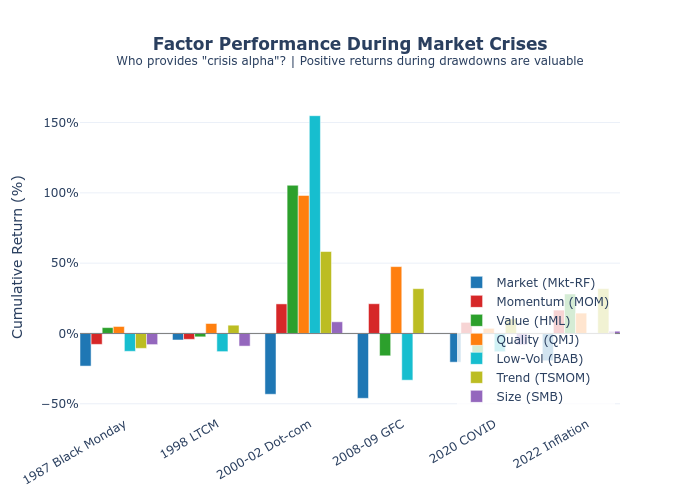

In [43]:
fig.update_layout(
    title=dict(
        text="<b>Factor Performance During Market Crises</b><br>"
        '<sup>Who provides "crisis alpha"? | Positive returns during drawdowns are valuable</sup>',
        x=0.5,
    ),
    xaxis=dict(
        tickmode="array",
        tickvals=x + len(available_factors) * bar_width / 2,
        ticktext=crisis_df.index,
        tickangle=-30,
    ),
    yaxis_title="Cumulative Return (%)",
    yaxis=dict(ticksuffix="%"),
    barmode="group",
    legend=dict(yanchor="bottom", y=0.01, xanchor="right", x=0.99, bgcolor="rgba(255,255,255,0.8)"),
    template="plotly_white",
    height=500,
)
fig.add_hline(y=0, line_color="gray", line_width=1)
fig.show()

**Interpretation**: Crisis performance is where correlations and premia become
economically meaningful. A factor that compounds nicely on average but fails exactly
when the rest of the portfolio is under stress is much less valuable in allocation.

### Crisis Performance Observations

1. **Market (Mkt-RF)**: By definition, large negative returns during crises.

2. **Momentum (MOM)**: Mixed results. Provided crisis alpha in some events but
   suffered the famous "momentum crash" in 2009 when the trend reversed violently.

3. **Value (HML)**: Generally negative during crises as cheap stocks get cheaper.
   The 2020 COVID crash was particularly painful for value.

4. **Quality (QMJ)**: Tends to provide some downside protection as investors
   "flight to quality" — preferring profitable, low-debt companies.

5. **Trend (TSMOM)**: When available, often provides the most consistent crisis
   alpha. The strategy naturally goes short when trends are down.

---

# Part 6: Comprehensive Summary Statistics

### Summary-Table Helper

The final table uses one row layout across French and AQR sources.

In [44]:
def append_summary_row(
    summary_stats: list[dict[str, object]],
    factor: str,
    source: str,
    returns: pd.Series,
    stats_dict: dict[str, float],
) -> None:
    """Append one formatted summary row for a factor series."""
    summary_stats.append(
        {
            "Factor": labels.get(factor, factor),
            "Source": source,
            "Period": f"{returns.index.min():%Y}-{returns.index.max():%Y}",
            "Ann. Return": f"{stats_dict['ann_return']:.1%}",
            "Ann. Volatility": f"{stats_dict['ann_vol']:.1%}",
            "Sharpe Ratio": f"{stats_dict['sharpe']:.2f}",
            "t-statistic": f"{stats_dict['t_stat']:.1f}",
            "Max Drawdown": f"{calculate_max_drawdown(returns):.1%}",
            "Skewness": f"{returns.skew():.2f}",
            "Months": len(returns),
        }
    )

In [45]:
# Build comprehensive summary table
summary_stats = []

# Fama-French factors
for factor in ["Mkt-RF", "HML", "SMB", "MOM"]:
    if factor in factor_stats:
        returns = ff4_pd[factor].dropna()
        s = factor_stats[factor]

        append_summary_row(summary_stats, factor, "French", returns, s)

# FF5 additional factors (ff5_pd already converted above)
for factor in ["RMW", "CMA"]:
    if factor in factor_stats:
        returns = ff5_pd[factor].dropna()
        s = factor_stats[factor]

        append_summary_row(summary_stats, factor, "French", returns, s)

# AQR factors
for factor, data in [("QMJ", qmj), ("BAB", bab)]:
    if data is not None and factor in factor_stats:
        data_pd = data.to_pandas().set_index("timestamp")
        col = "USA" if "USA" in data_pd.columns else data_pd.columns[0]
        returns = data_pd[col].dropna()
        s = factor_stats[factor]

        append_summary_row(summary_stats, factor, "AQR", returns, s)

summary_df = pd.DataFrame(summary_stats).set_index("Factor")
summary_df

,Source,Period,Ann. Return,Ann. Volatility,Sharpe Ratio,t-statistic,Max Drawdown,Skewness,Months
Factor,,,,,,,,,
Market (Mkt-RF),French,1926-2026,8.3%,18.4%,0.45,4.4,-84.6%,0.15,1196
Value (HML),French,1926-2026,4.2%,12.3%,0.34,3.1,-57.8%,2.04,1196
Size (SMB),French,1926-2026,2.0%,10.9%,0.18,1.8,-54.9%,1.78,1196
Momentum (MOM),French,1927-2026,7.3%,16.2%,0.45,4.6,-78.6%,-3.06,1190
Profitability (RMW),French,1963-2026,3.2%,7.7%,0.42,3.0,-41.8%,-0.32,752
Investment (CMA),French,1963-2026,3.0%,7.2%,0.42,2.9,-27.2%,0.27,752
Quality (QMJ),AQR,1957-2026,4.0%,7.8%,0.50,3.7,-29.3%,0.04,825
Low-Vol (BAB),AQR,1930-2026,7.9%,11.1%,0.71,5.7,-54.6%,-0.67,1144


---

## Key Takeaways

- **Factor-return diagnostics**: Harvey-style Newey-West t-statistics on the
  long pre-publication AQR/French series confirm that value, momentum, quality,
  and BAB premia clear the t > 3 bar, while the size premium (SMB) has decayed
  to economic and statistical insignificance post-1981.
- **Crisis behavior**: No factor delivers consistent crisis alpha. TSMOM
  provides the most reliable downside hedge; QMJ partially offsets
  "flight-to-quality" episodes; HML and MOM are crisis-sensitive (notably
  2009 momentum crash, 2020 value drawdown).
- **Correlation structure**: Value-momentum correlation hovers near
  ρ ≈ −0.2 across regions and asset classes (cross-asset "Value and Momentum
  Everywhere" evidence), driving the diversification rationale for combining
  the two in allocation.

## References

- Asness, Moskowitz & Pedersen (2013), "Value and Momentum Everywhere"
- Harvey, Liu & Zhu (2016), "...and the Cross-Section of Expected Returns"
- Ilmanen et al. (2021), "How Do Factor Premia Vary Over Time?"
- Moskowitz, Ooi & Pedersen (2012), "Time Series Momentum"
- Lo (2002), "The Statistics of Sharpe Ratios"

Full bibliography and Data Library / AQR licensing details live in the
chapter prose.